In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

X = df[['Annual Income (k$)','Spending Score (1-100)']]

# Model
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualization
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()



In [ ]:

sns.scatterplot(data = df, x = "Annual Income (k$)",y = "Spending Score (1-100)", hue = 'Cluster')
df[df["Cluster"] == 3]



Best K: 5
[0.39564531743995546, 0.46761358158775435, 0.4937945814354117, 0.553931997444648, 0.5128405328004378, 0.5017174409749505, 0.4962769338093321, 0.45587414130065596, 0.4426214845978157]


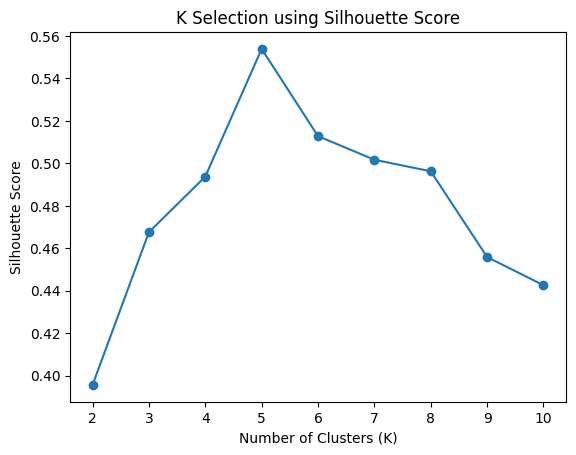

In [28]:
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

X = df[['Annual Income (k$)','Spending Score (1-100)']]

k_values = range(2, 11)
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    scores.append(score)

# Best K
best_k = k_values[scores.index(max(scores))]
print("Best K:", best_k)
print(scores)
# Plot scores
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K Selection using Silhouette Score")
plt.show()

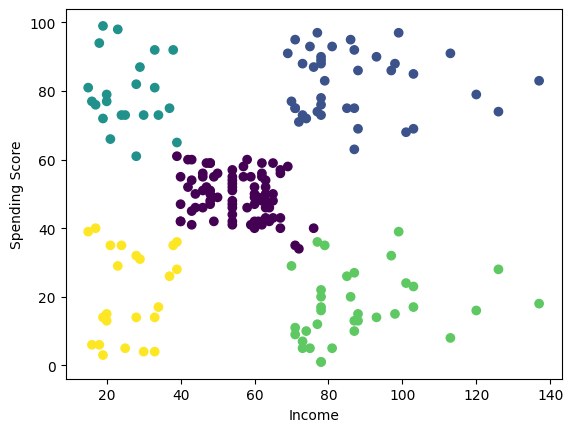

In [29]:
kmeans = KMeans(n_clusters=best_k, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()